In [126]:
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
df = pd.read_csv("../data/iris.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,iris_type
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [128]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,iris_type
29,4.7,3.2,1.6,0.2,Iris-setosa
63,6.1,2.9,4.7,1.4,Iris-versicolor
67,5.8,2.7,4.1,1.0,Iris-versicolor
36,5.5,3.5,1.3,0.2,Iris-setosa
54,6.5,2.8,4.6,1.5,Iris-versicolor
95,5.7,3.0,4.2,1.2,Iris-versicolor
44,5.1,3.8,1.9,0.4,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
18,5.7,3.8,1.7,0.3,Iris-setosa
66,5.6,3.0,4.5,1.5,Iris-versicolor


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   iris_type     150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [130]:
df["iris_type"] != "Iris-virginica"

0       True
1       True
2       True
3       True
4       True
       ...  
145    False
146    False
147    False
148    False
149    False
Name: iris_type, Length: 150, dtype: bool

In [131]:
df = df[df["iris_type"] != "Iris-virginica"]

In [132]:
print(df["iris_type"].unique())
print("Rows left:", len(df))

<StringArray>
['Iris-setosa', 'Iris-versicolor']
Length: 2, dtype: str
Rows left: 100


In [133]:
class_counts = df["iris_type"].value_counts()
print(class_counts)

#response for q1-- How balanced are the two classes?
#They're dead even, 50 Setosa and 50 Versicolor. So a 50/50 split.
#That's good because it means accuracy actually tells me something. If the
#split was like 90/10, the model could just guess the big class every single
#time and still look like it was 90% right, even though it never learned
#anything. Here, guessing one class the whole time only gets me 50%, so if I
#end up above that the model is picking up on something real.

iris_type
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64


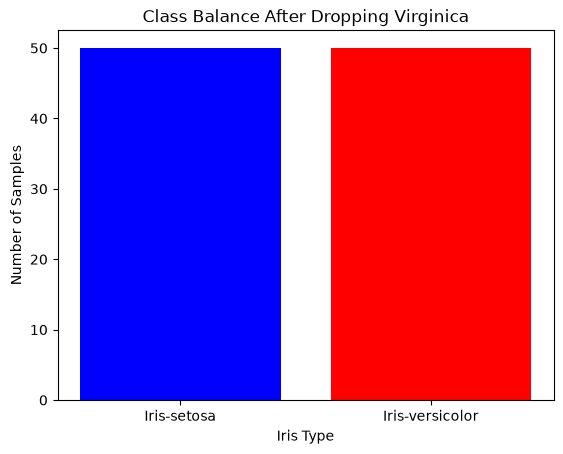

In [134]:
plt.bar(class_counts.index, class_counts.values, color=["blue", "red"])
plt.xlabel("Iris Type")
plt.ylabel("Number of Samples")
plt.title("Class Balance After Dropping Virginica")
plt.show()


In [135]:
setosa = df[df["iris_type"] == "Iris-setosa"]
versicolor = df[df["iris_type"] == "Iris-versicolor"]

In [136]:
print(len(setosa), len(versicolor))

50 50


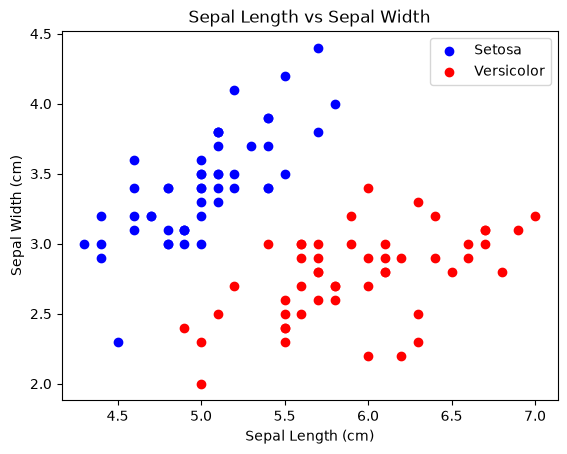

In [137]:
plt.scatter(setosa["sepal_length"], setosa["sepal_width"],
            color="blue", label="Setosa")
plt.scatter(versicolor["sepal_length"], versicolor["sepal_width"],
            color="red", label="Versicolor")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.legend()
plt.show()

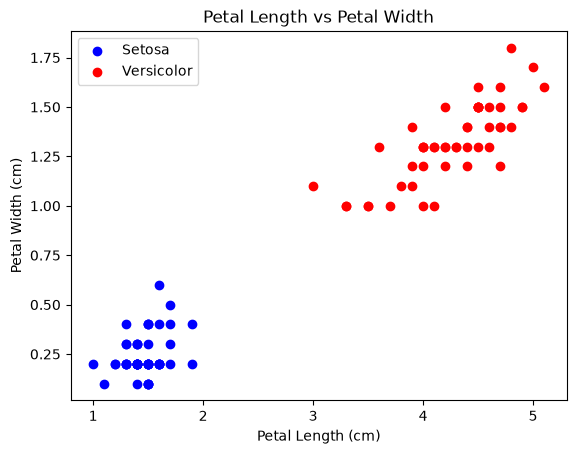

In [138]:
plt.scatter(setosa["petal_length"], setosa["petal_width"],
            color="blue", label="Setosa")
plt.scatter(versicolor["petal_length"], versicolor["petal_width"],
            color="red", label="Versicolor")

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.show()

# What I see here---
# This one is way cleaner than the sepal plot. The two groups are sitting in
# completely different corners with a big empty gap in between. Setosa petals
# are tiny (length about 1.0 to 1.9) and Versicolor petals are much bigger
# (about 3.0 to 5.1), so there's roughly a whole centimeter where nothing
# shows up at all. Nothing overlaps here.

In [139]:
#response for q2-- Which feature pair shows the best separation?
#Petal length vs petal width, not even close. The sepal plot has the two colors
#squished together in the middle, but the petal plot has them in totally
#different corners with a big gap. iris.info backs this up, petal length and
#width have the highest correlation with the class (0.949 and 0.957) while
#sepal width is negative (-0.419).

#response for q3-- Does the data appear linearly separable?
#Yes. On the petal plot I could draw one straight line through the gap and every
#point would land on the right side. The sepal plot works too but it's way
#tighter. This is only true because I dropped Virginica though, since Versicolor
#and Virginica overlap and no single line would work with all three.

#response for q4-- What challenges might a simple model (like a perceptron) face?
#The features are on different scales, sepal length goes 4.3 to 7.0 but petal
#width only 0.1 to 1.8, so the bigger numbers push the weighted sum around more.
#It also stops at ANY line that works instead of the best one, so the boundary
#could sit right against the training points and miss a new flower near the edge.
#And it only draws one straight line, which is why curved boundaries need
#multi layer networks.